In [22]:
import os, json, time, random
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import albumentations as A
import torchvision.models as tv_models
import gc

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

SPLITS_PATH = "/kaggle/input/notebooks/sumaiyahoque/nb-04-partb-data-prep/splits"
IMG_SIZE, NUM_CLASSES, MASK_THRESHOLD = 512, 2, 127
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

train_df = pd.read_csv(f"{SPLITS_PATH}/train_unlabelled.csv")
val_df = pd.read_csv(f"{SPLITS_PATH}/val_labelled_finetune.csv")
test_df = pd.read_csv(f"{SPLITS_PATH}/test_monitor_eval.csv")

print(f"Train (unlabelled): {len(train_df)} | Val (labelled FT): {len(val_df)} | Test: {len(test_df)}")

with open(f"{SPLITS_PATH}/split_meta.json", "r") as f:
    split_meta = json.load(f)

print(json.dumps(split_meta, indent=2))

FG_PCT = 0.08
class_weights = torch.tensor([1/(1-FG_PCT), 1/FG_PCT], dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)
print("Data loaded successfully.")

Device: cuda
Train (unlabelled): 1035 | Val (labelled FT): 318 | Test: 168
{
  "dataset": "BCSD-2024 breast ultrasound lesion segmentation",
  "num_classes": 2,
  "class_names": [
    "background",
    "lesion"
  ],
  "img_size": 512,
  "mask_threshold": 127,
  "train_count": 1035,
  "val_count": 318,
  "test_count": 168,
  "part_a_best_model": "SegFormer-B0",
  "part_a_best_miou": 0.8758,
  "label_efficiency_ratio": 0.3072,
  "source": "Part A leakage-safe patient-level split (nb-0), roles reassigned for Part B"
}
Class weights: tensor([0.1600, 1.8400], device='cuda:0')
Data loaded successfully.


SimCLR Encoder

In [23]:
class SimCLREncoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
        self.stem = nn.Sequential(*list(backbone.children())[:-2])  
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj_head = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(inplace=True), nn.Linear(512, 128))  

    def forward(self, x, return_features=False):
        feat_map = self.stem(x)              
        pooled = self.pool(feat_map).flatten(1)
        z = self.proj_head(pooled)
        if return_features:
            return feat_map
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=0.5):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)                     
    sim = torch.mm(z, z.t()) / temperature              
    sim.fill_diagonal_(-1e9)                            
    targets = torch.cat([torch.arange(B,2*B), torch.arange(0,B)]).to(z.device)  
    return F.cross_entropy(sim, targets)

two view dataset and 50epoch pretraining loop

In [28]:
for name in ["encoder", "optimizer", "scheduler", "scaler", "ssl_train_loader", "ssl_train_ds"]:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

def nt_xent_loss(z1, z2, temperature=0.5):
    B = z1.size(0)

    z1 = F.normalize(z1.float(), dim=1, eps=1e-8)
    z2 = F.normalize(z2.float(), dim=1, eps=1e-8)

    z = torch.cat([z1, z2], dim=0)
    logits = torch.mm(z, z.t()) / temperature

    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    logits = logits.masked_fill(mask, float("-inf"))

    targets = torch.cat([
        torch.arange(B, 2 * B, device=z.device),
        torch.arange(0, B, device=z.device)
    ])

    return F.cross_entropy(logits, targets)

class TwoViewDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["img_path"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.cvtColor(
            cv2.imread(self.paths[idx]),
            cv2.COLOR_BGR2RGB
        )

        v1 = self.transform(image=img)["image"]
        v2 = self.transform(image=img)["image"]

        def norm(v):
            v = ((v.astype(np.float32) / 255.0) - IMAGENET_MEAN) / IMAGENET_STD
            return torch.from_numpy(v.transpose(2, 0, 1)).float()

        return norm(v1), norm(v2)

SSL_IMG_SIZE = 224

ssl_train_transform = A.Compose([
    A.RandomResizedCrop(
        size=(SSL_IMG_SIZE, SSL_IMG_SIZE),
        scale=(0.2, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(0.4, 0.4, p=0.8),
    A.ToGray(p=0.2),
    A.GaussianBlur((3, 5), p=0.5),
])

ssl_train_ds = TwoViewDataset(
    train_df,
    ssl_train_transform
)

ssl_train_loader = DataLoader(
    ssl_train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    drop_last=True,
    pin_memory=True
)

encoder = SimCLREncoder().to(DEVICE)

optimizer = torch.optim.AdamW(
    encoder.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

PRETRAIN_CONFIG = {
    "method": "SimCLR",
    "backbone": "ResNet-50 (ImageNet-init, continued SSL)",
    "epochs": 50,
    "batch_size": 8,
    "ssl_image_size": 224,
    "temperature": 0.5,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "mixed_precision": True,
    "nt_xent": "Float32 cosine-similarity stable implementation"
}

print(json.dumps(PRETRAIN_CONFIG, indent=2))

pretext_losses = []
start = time.time()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)

for epoch in range(1, 51):
    encoder.train()
    running = 0.0
    epoch_t0 = time.time()

    for v1, v2 in ssl_train_loader:
        v1 = v1.to(DEVICE, non_blocking=True)
        v2 = v2.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):
            z1 = encoder(v1)
            z2 = encoder(v2)

        loss = nt_xent_loss(
            z1,
            z2,
            temperature=PRETRAIN_CONFIG["temperature"]
        )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()

    scheduler.step()

    avg_loss = running / len(ssl_train_loader)
    pretext_losses.append(avg_loss)

    print(
        f"[SimCLR] Epoch {epoch:02d} | "
        f"NT-Xent loss={avg_loss:.4f} | "
        f"time={time.time() - epoch_t0:.1f}s"
    )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

pretrain_time_min = (time.time() - start) / 60

print(
    f"\nSSL pretraining completed | "
    f"Final loss={pretext_losses[-1]:.4f} | "
    f"Time={pretrain_time_min:.2f} minutes"
)

{
  "method": "SimCLR",
  "backbone": "ResNet-50 (ImageNet-init, continued SSL)",
  "epochs": 50,
  "batch_size": 8,
  "ssl_image_size": 224,
  "temperature": 0.5,
  "optimizer": "AdamW",
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "mixed_precision": true,
  "nt_xent": "Float32 cosine-similarity stable implementation"
}
[SimCLR] Epoch 01 | NT-Xent loss=2.1273 | time=24.1s
[SimCLR] Epoch 02 | NT-Xent loss=1.7762 | time=23.2s
[SimCLR] Epoch 03 | NT-Xent loss=1.5949 | time=21.8s
[SimCLR] Epoch 04 | NT-Xent loss=1.4931 | time=24.5s
[SimCLR] Epoch 05 | NT-Xent loss=1.4750 | time=21.2s
[SimCLR] Epoch 06 | NT-Xent loss=1.4018 | time=23.3s
[SimCLR] Epoch 07 | NT-Xent loss=1.3815 | time=21.9s
[SimCLR] Epoch 08 | NT-Xent loss=1.3630 | time=22.0s
[SimCLR] Epoch 09 | NT-Xent loss=1.3520 | time=22.3s
[SimCLR] Epoch 10 | NT-Xent loss=1.3444 | time=21.3s
[SimCLR] Epoch 11 | NT-Xent loss=1.3256 | time=22.4s
[SimCLR] Epoch 12 | NT-Xent loss=1.2880 | time=24.6s
[SimCLR] Epoch 13 | NT-Xent loss=1.2581 | 

 Pretext Loss Curve

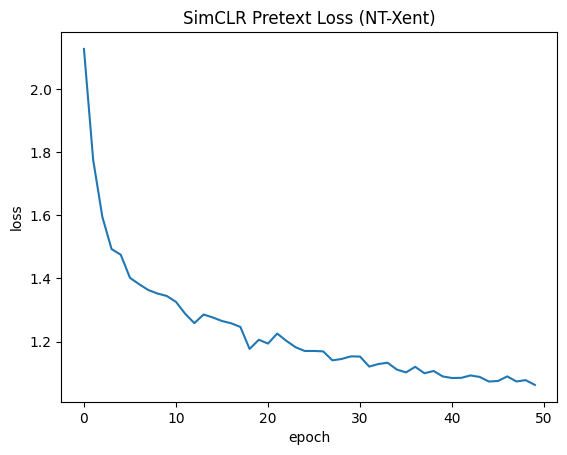

Pretraining wall-clock time: 19.0 min (0.38 min/epoch)


In [29]:
plt.plot(pretext_losses); plt.title("SimCLR Pretext Loss (NT-Xent)"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.show()
print(f"Pretraining wall-clock time: {pretrain_time_min:.1f} min "
      f"({pretrain_time_min/50:.2f} min/epoch)")
torch.save(encoder.state_dict(), "/kaggle/working/simclr_encoder.pt")

Attach SegFormer-B0 

In [30]:
from transformers.models.segformer.modeling_segformer import SegformerDecodeHead, SegformerConfig

def build_segformer_decoder(in_channels_list, hidden_size=256, num_classes=NUM_CLASSES):
    """Reuses Part-A's SegFormer-B0 All-MLP head design: per-stage MLP -> upsample -> concat -> classify."""
    cfg = SegformerConfig(num_labels=num_classes, decoder_hidden_size=hidden_size,
                           hidden_sizes=in_channels_list, num_encoder_blocks=len(in_channels_list),
                           reshape_last_stage=True)
    return SegformerDecodeHead(cfg)

class SimCLRSegModel(nn.Module):
    """ResNet-50 (SimCLR-pretrained) encoder + SegFormer All-MLP decode head."""
    def __init__(self, encoder, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        self.adapter = nn.ModuleList([
            nn.Conv2d(2048, c, kernel_size=1) for c in [64, 128, 320, 512]
        ])
        self.decode_head = build_segformer_decoder(in_channels_list=[64,128,320,512])
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad = False

    def forward(self, x):
        feat_map = self.encoder(x, return_features=True)          
        stage_feats = [adapt(feat_map) for adapt in self.adapter]  
        logits = self.decode_head(stage_feats)                     
        return F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

frozen vs fine tuned

In [32]:
finetune_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.Affine(
        translate_percent=(-0.05, 0.05),
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.4
    ),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
    A.GaussianBlur((3, 5), p=0.2),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE)
])

class SegDataset(Dataset):
    def __init__(self, df, transform=None, mask_threshold=MASK_THRESHOLD):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.mt = mask_threshold

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask >= self.mt).astype(np.uint8)

        if mask.shape[:2] != img.shape[:2]:
            mask = cv2.resize(
                mask,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        img = (
            (img.astype(np.float32) / 255.0)
            - IMAGENET_MEAN
        ) / IMAGENET_STD

        img = torch.from_numpy(
            img.transpose(2, 0, 1)
        ).float()

        mask = torch.from_numpy(mask).long()

        return img, mask, row["img_path"]

finetune_ds = SegDataset(val_df, finetune_transform)
test_ds = SegDataset(test_df, test_transform)

finetune_loader = DataLoader(
    finetune_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

def compute_miou(preds, targets, num_classes=NUM_CLASSES):
    ious = []

    for c in range(num_classes):
        p = preds == c
        t = targets == c

        inter = (p & t).sum().item()
        union = (p | t).sum().item()

        if union > 0:
            ious.append(inter / union)

    return float(np.mean(ious)) if ious else 0.0

def dice_loss_fn(logits, targets, eps=1e-6):
    probs = F.softmax(logits, dim=1)[:, 1]
    t = targets.float()

    inter = (probs * t).sum((1, 2))
    union = probs.sum((1, 2)) + t.sum((1, 2))

    return 1 - ((2 * inter + eps) / (union + eps)).mean()

def compute_loss(logits, masks):
    return (
        0.5 * ce_loss_fn(logits, masks)
        + 0.5 * dice_loss_fn(logits, masks)
    )

@torch.no_grad()
def evaluate(loader, model):
    model.eval()

    total_loss = 0.0
    total_miou = 0.0
    n = 0

    for imgs, masks, _ in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):
            logits = model(imgs)
            loss = compute_loss(logits, masks)

        total_loss += loss.item()
        total_miou += compute_miou(
            logits.argmax(1),
            masks
        )
        n += 1

    return total_loss / n, total_miou / n

PROBE_EPOCHS = 10
probe_results = {}

for freeze in [True, False]:

    tag = "frozen" if freeze else "finetuned"

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    probe_model = SimCLRSegModel(
        SimCLREncoder().to(DEVICE),
        freeze_encoder=freeze
    ).to(DEVICE)

    probe_model.encoder.load_state_dict(
        torch.load(
            "/kaggle/working/simclr_encoder.pt",
            map_location=DEVICE
        )
    )

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, probe_model.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(DEVICE.type == "cuda")
    )

    epoch_history = []
    best_epoch = 1
    best_miou = -1.0

    for epoch in range(1, PROBE_EPOCHS + 1):

        probe_model.train()
        running_loss = 0.0
        n_batches = 0

        for imgs, masks, _ in finetune_loader:

            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE.type == "cuda")
            ):
                logits = probe_model(imgs)
                loss = compute_loss(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches

        _, train_miou = evaluate(
            finetune_loader,
            probe_model
        )

        epoch_history.append({
            "epoch": epoch,
            "loss": train_loss,
            "mIoU": train_miou
        })

        if train_miou > best_miou:
            best_miou = train_miou
            best_epoch = epoch

        print(
            f"[Probe] {tag} | "
            f"Epoch {epoch:02d}/{PROBE_EPOCHS} | "
            f"Loss={train_loss:.4f} | "
            f"mIoU={train_miou:.4f}"
        )

    test_loss, test_miou = evaluate(
        test_loader,
        probe_model
    )

    probe_results[tag] = {
        "best_epoch": best_epoch,
        "best_train_miou": best_miou,
        "test_loss": test_loss,
        "test_mIoU": test_miou,
        "history": epoch_history
    }

    print(
        f"[Probe Result] {tag} | "
        f"Best Epoch={best_epoch} | "
        f"Best mIoU={best_miou:.4f} | "
        f"Test mIoU={test_miou:.4f}"
    )

    del probe_model, opt, scaler

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

print(json.dumps(
    {
        k: {
            "best_epoch": v["best_epoch"],
            "best_train_miou": v["best_train_miou"],
            "test_loss": v["test_loss"],
            "test_mIoU": v["test_mIoU"]
        }
        for k, v in probe_results.items()
    },
    indent=2
))

[Probe] frozen | Epoch 01/10 | Loss=0.6600 | mIoU=0.5175
[Probe] frozen | Epoch 02/10 | Loss=0.5891 | mIoU=0.5565
[Probe] frozen | Epoch 03/10 | Loss=0.5638 | mIoU=0.5546
[Probe] frozen | Epoch 04/10 | Loss=0.5477 | mIoU=0.5630
[Probe] frozen | Epoch 05/10 | Loss=0.5354 | mIoU=0.5646
[Probe] frozen | Epoch 06/10 | Loss=0.5279 | mIoU=0.5672
[Probe] frozen | Epoch 07/10 | Loss=0.5170 | mIoU=0.5741
[Probe] frozen | Epoch 08/10 | Loss=0.5171 | mIoU=0.5801
[Probe] frozen | Epoch 09/10 | Loss=0.5074 | mIoU=0.5682
[Probe] frozen | Epoch 10/10 | Loss=0.5055 | mIoU=0.5763
[Probe Result] frozen | Best Epoch=8 | Best mIoU=0.5801 | Test mIoU=0.5798
[Probe] finetuned | Epoch 01/10 | Loss=0.6365 | mIoU=0.5414
[Probe] finetuned | Epoch 02/10 | Loss=0.5430 | mIoU=0.5706
[Probe] finetuned | Epoch 03/10 | Loss=0.5129 | mIoU=0.5918
[Probe] finetuned | Epoch 04/10 | Loss=0.4921 | mIoU=0.5961
[Probe] finetuned | Epoch 05/10 | Loss=0.4773 | mIoU=0.5991
[Probe] finetuned | Epoch 06/10 | Loss=0.4664 | mIoU=0.

In [34]:
FROZEN_ENCODER = False  

50 epoch Supervised finetuning

In [38]:
model = SimCLRSegModel(SimCLREncoder().to(DEVICE), freeze_encoder=FROZEN_ENCODER).to(DEVICE)
model.encoder.load_state_dict(torch.load("/kaggle/working/simclr_encoder.pt", map_location=DEVICE))
model = model.to(DEVICE)

FT_CONFIG = {
    "model":"SimCLR-ResNet50 + SegFormer-Head",
    "frozen_encoder":FROZEN_ENCODER,
    "epochs":50,
    "batch_size":8,
    "encoder_lr":1e-5,
    "decoder_lr":1e-4,
    "optimizer":"AdamW",
    "schedule":"CosineAnnealingLR",
    "input_size":IMG_SIZE,
    "loss":"0.5*CE(weighted)+0.5*Dice"
}
print(json.dumps(FT_CONFIG, indent=2))

param_groups = [
    {"params": model.decode_head.parameters(), "lr": FT_CONFIG["decoder_lr"]},
    {"params": model.adapter.parameters(), "lr": FT_CONFIG["decoder_lr"]}
]

if not FROZEN_ENCODER:
    param_groups.append({
        "params": model.encoder.parameters(),
        "lr": FT_CONFIG["encoder_lr"]
    })

optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

ft_loader = DataLoader(
    finetune_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    drop_last=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

history = {"train_loss": [], "test_loss": [], "test_miou": []}
best_miou, best_epoch = -1, -1
ft_start = time.time()

for epoch in range(1, 51):
    model.train()
    running = 0.0
    t0 = time.time()

    for imgs, masks, _ in ft_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = compute_loss(model(imgs), masks)
        loss.backward()
        optimizer.step()

        running += loss.item()

    scheduler.step()

    train_loss = running / len(ft_loader)

    test_loss, test_miou = evaluate(test_loader, model)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_miou"].append(test_miou)

    print(
        f"[SimCLR-FT] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"test_loss={test_loss:.4f} | "
        f"test_mIoU={test_miou:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )

    if test_miou > best_miou:
        best_miou = test_miou
        best_epoch = epoch
        torch.save(
            model.state_dict(),
            "/kaggle/working/simclr_seg_best.pt"
        )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

ft_time_min = (time.time() - ft_start) / 60

model.load_state_dict(
    torch.load(
        "/kaggle/working/simclr_seg_best.pt",
        map_location=DEVICE
    )
)

print(
    f"\nFine-tuning complete in {ft_time_min:.1f} min. "
    f"Best test mIoU={best_miou:.4f} at epoch {best_epoch}."
)

{
  "model": "SimCLR-ResNet50 + SegFormer-Head",
  "frozen_encoder": false,
  "epochs": 50,
  "batch_size": 8,
  "encoder_lr": 1e-05,
  "decoder_lr": 0.0001,
  "optimizer": "AdamW",
  "schedule": "CosineAnnealingLR",
  "input_size": 512,
  "loss": "0.5*CE(weighted)+0.5*Dice"
}
[SimCLR-FT] Epoch 01 | train_loss=0.6922 | test_loss=0.6304 | test_mIoU=0.5459 | time=26.1s
[SimCLR-FT] Epoch 02 | train_loss=0.5991 | test_loss=0.5788 | test_mIoU=0.5619 | time=25.8s
[SimCLR-FT] Epoch 03 | train_loss=0.5632 | test_loss=0.5566 | test_mIoU=0.6011 | time=24.8s
[SimCLR-FT] Epoch 04 | train_loss=0.5387 | test_loss=0.5293 | test_mIoU=0.6194 | time=25.1s
[SimCLR-FT] Epoch 05 | train_loss=0.5237 | test_loss=0.4667 | test_mIoU=0.6554 | time=25.7s
[SimCLR-FT] Epoch 06 | train_loss=0.5120 | test_loss=0.4934 | test_mIoU=0.6348 | time=25.4s
[SimCLR-FT] Epoch 07 | train_loss=0.5001 | test_loss=0.5030 | test_mIoU=0.6301 | time=25.3s
[SimCLR-FT] Epoch 08 | train_loss=0.4899 | test_loss=0.4849 | test_mIoU=0.6461

fine tuning curves

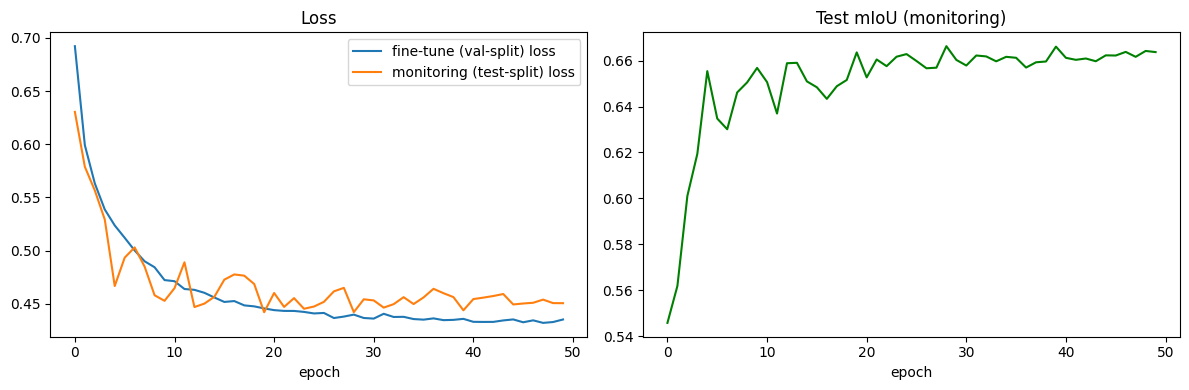

In [39]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="fine-tune (val-split) loss")
axes[0].plot(history["test_loss"], label="monitoring (test-split) loss"); axes[0].legend()
axes[0].set_xlabel("epoch"); axes[0].set_title("Loss")
axes[1].plot(history["test_miou"], color="green"); axes[1].set_title("Test mIoU (monitoring)")
axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

final test

In [40]:
@torch.no_grad()
def full_test_evaluation(loader, forward_fn, num_classes=NUM_CLASSES):
    all_preds, all_targets, per_image_iou = [], [], []
    cm_total = np.zeros((num_classes,num_classes), dtype=np.int64)
    for imgs, masks, paths in loader:
        logits = forward_fn(imgs.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy(); targets = masks.numpy()
        for p, t, path in zip(preds, targets, paths):
            per_image_iou.append((path, compute_miou(torch.tensor(p), torch.tensor(t), num_classes)))
            cm_total += confusion_matrix(t.flatten(), p.flatten(), labels=list(range(num_classes)))
        all_preds.append(preds.flatten()); all_targets.append(targets.flatten())
    all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)
    per_class_iou, dice_scores = [], []
    for c in range(num_classes):
        p, t = (all_preds==c), (all_targets==c)
        inter, union = (p&t).sum(), (p|t).sum()
        per_class_iou.append(inter/union if union>0 else 0.0)
        dice_scores.append(2*inter/(p.sum()+t.sum()+1e-8))
    miou = float(np.mean(per_class_iou))
    pix_acc = (all_preds==all_targets).mean()
    per_class_acc = [(all_preds[all_targets==c]==c).mean() for c in range(num_classes) if (all_targets==c).sum()>0]
    return {"mIoU": miou, "per_class_iou": [float(x) for x in per_class_iou],
            "overall_pixel_accuracy": float(pix_acc), "mean_pixel_accuracy": float(np.mean(per_class_acc)),
            "mean_dice": float(np.mean(dice_scores)), "dice_per_class": [float(x) for x in dice_scores],
            "confusion_matrix": cm_total.tolist(), "per_image_iou": per_image_iou}

test_results = full_test_evaluation(test_loader, lambda x: model(x))
print(f"SimCLR test mIoU: {test_results['mIoU']:.4f}  (Part-A SegFormer baseline: 0.8758)")
print(f"Fine-tuned on {len(finetune_ds)} labelled images vs. Part-A's {len(train_df)}")
print(f"Label-efficiency: recovered {test_results['mIoU']/0.8758:.1%} of full-supervision mIoU "
      f"using {len(finetune_ds)/len(train_df):.1%} of the labels")

SimCLR test mIoU: 0.7232  (Part-A SegFormer baseline: 0.8758)
Fine-tuned on 318 labelled images vs. Part-A's 1035
Label-efficiency: recovered 82.6% of full-supervision mIoU using 30.7% of the labels


confusion matrix

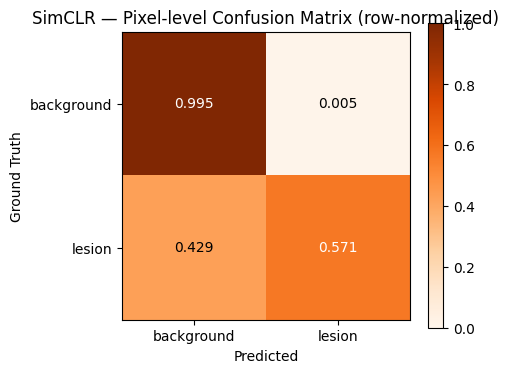

In [41]:
cm = np.array(test_results["confusion_matrix"])
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_norm, cmap="Oranges", vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_xticklabels(["background","lesion"])
ax.set_yticks([0,1]); ax.set_yticklabels(["background","lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title("SimCLR — Pixel-level Confusion Matrix (row-normalized)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i,j]:.3f}", ha="center", va="center",
                 color="white" if cm_norm[i,j] > 0.5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

error

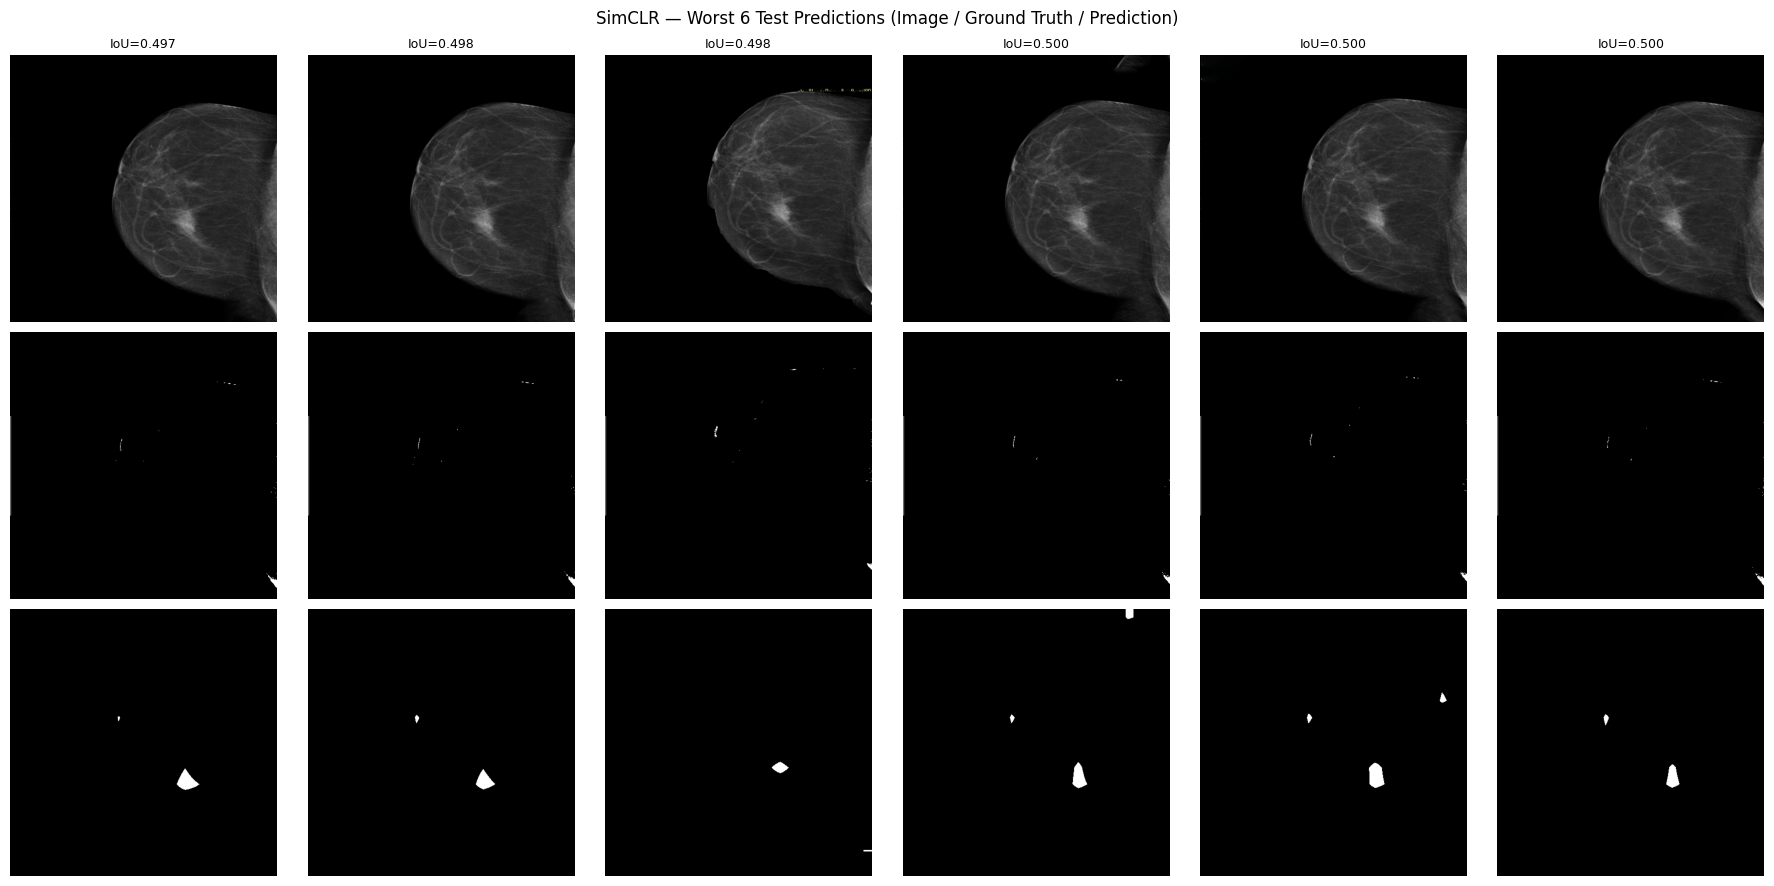

In [42]:
worst = sorted(test_results["per_image_iou"], key=lambda x: x[1])[:6]
fig, axes = plt.subplots(3, 6, figsize=(18,9))
for col, (path, iou) in enumerate(worst):
    row = test_ds.df[test_ds.df["img_path"]==path].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    gt = (cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE) >= MASK_THRESHOLD).astype(np.uint8)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)); gt_r = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    t = ((img_r.astype(np.float32)/255.)-IMAGENET_MEAN)/IMAGENET_STD
    t = torch.from_numpy(t.transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad(): pred = model(t).argmax(1).squeeze(0).cpu().numpy()
    axes[0,col].imshow(img_r); axes[0,col].set_title(f"IoU={iou:.3f}", fontsize=9)
    axes[1,col].imshow(gt_r, cmap="gray"); axes[2,col].imshow(pred, cmap="gray")
    for r in range(3): axes[r,col].axis("off")
axes[0,0].set_ylabel("Image"); axes[1,0].set_ylabel("GT"); axes[2,0].set_ylabel("Pred")
plt.suptitle("SimCLR — Worst 6 Test Predictions (Image / Ground Truth / Prediction)")
plt.tight_layout(); plt.show()

In [43]:
def append_results(method_name, summary, results_path="/kaggle/working/results_B.json"):
    all_results = json.load(open(results_path)) if os.path.exists(results_path) else {}
    all_results[method_name] = summary
    json.dump(all_results, open(results_path, "w"), indent=2)
    print(f"Saved {method_name} results.")

append_results("SimCLR", {
    "pretrain_config": PRETRAIN_CONFIG,
    "finetune_config": FT_CONFIG,
    "pretrain_time_min": round(pretrain_time_min, 2),
    "finetune_time_min": round(ft_time_min, 2),
    "best_epoch": best_epoch,
    "test_metrics": test_results,
})

Saved SimCLR results.
